<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [1]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.5/204.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.5 MB/s eta 0:00:00


In [1]:
!pip install table_evaluator

In [1]:
!pip install dython

# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [58]:
from google.colab import files
uploaded = files.upload()

Saving Biohydrogen_production.csv to Biohydrogen_production (1).csv


In [59]:
import pandas as pd
data = pd.read_csv('Biohydrogen_production (1).csv')

In [60]:
real_data = pd.read_csv('Biohydrogen_production (1).csv')

In [61]:
display(real_data.head(35))

,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,Water,3,No,81,1183,898,1520,553,4155,0.0026,42.62,4.11,11.45,7.64,0.9859
1,Water,3,Yes,50,1593,1445,1594,754,5388,0.0016,27.05,2.21,10.60,6.1,0.9973
2,H2SO4,3,No,36,519,114,222,89,991,0.1911,22.54,0.36,14.14,−8.89,0.9735
3,H2SO4,10,No,29,876,118,666,3940,1897,0.1048,39.44,0.84,21.77,4.5,0.9898
4,H2SO4,20,No,23,720,90,284,188,1283,0.0335,26.76,0.71,9.58,−4.29,0.9735
5,H2SO4,25,No,96,1184,100,377,51,1714,0.0244,23.29,1.22,8.00,0.98,0.9742
6,H2SO4,3,Yes,94,683,114,121,58,1009,0.1054,12.92,0.43,14.86,3.81,0.9913
7,H2SO4,10,Yes,77,1201,494,1359,1202,4257,0.1237,49.72,1.44,18.03,5.33,0.9946
8,H2SO4,20,Yes,86,1311,855,4923,2057,9147,0.1313,104.03,2.24,23.26,6.17,0.9984
9,H2SO4,25,Yes,83,1681,3005,8014,7168,"42,287",0.1429,144.22,3.16,25.67,8.88,0.9989


The demo also includes **metadata**, a description of the dataset. It includes the primary keys as well as the data types for each column (called "sdtypes").

In [70]:
categorical_features = ['Catalyst', 'Nutrient']

Table name configured: Biohydrogen_production_table
Updated Metadata:
{'Catalyst': {'sdtype': 'categorical'}, 'RS conc. (g/L)': {'sdtype': 'numerical'}, 'Nutrient': {'sdtype': 'categorical'}, 'Sugar consumed (%)': {'sdtype': 'numerical'}, 'HAc (mg/L)': {'sdtype': 'numerical'}, 'HPr (mg/L)': {'sdtype': 'numerical'}, 'n-Hbu (mg/L)': {'sdtype': 'numerical'}, 'i-Hbu (mg/L)': {'sdtype': 'numerical'}, 'TVFA (mg/L)': {'sdtype': 'numerical'}, 'HY mmol/g rice straw': {'sdtype': 'numerical'}, 'P\xa0(ml)': {'sdtype': 'numerical'}, 'Rm\xa0(ml/h)': {'sdtype': 'numerical'}, 'tm\xa0(h)': {'sdtype': 'numerical'}, 'λ\xa0(h)': {'sdtype': 'numerical'}, 'R-square': {'sdtype': 'numerical'}}
Primary key for table: None
Metadata visualization:


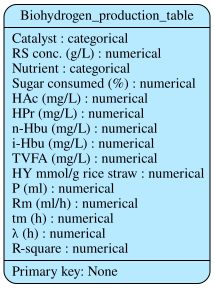

In [84]:
from sdv.metadata import Metadata
from IPython.display import display

user_desired_table_name = 'Biohydrogen_production_table'

# Initialize metadata by detecting from the dataframe with the desired table name.
# This method will automatically infer column types and other metadata details.
metadata = Metadata.detect_from_dataframe(data=real_data, table_name=user_desired_table_name)

# Now, update column sdtypes based on categorical_features list by directly modifying the columns dictionary
for col in real_data.columns:
    if col in categorical_features:
        metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'categorical'
    else:
        # For numerical columns, ensure they are set to numerical.
        # Explicitly setting is safer as default detection might categorize some numbers as discrete.
        metadata.tables[user_desired_table_name].columns[col]['sdtype'] = 'numerical'

# Explicitly ensure no primary key is set for the table
# This is done by directly setting the primary_key attribute of the table metadata
metadata.tables[user_desired_table_name].primary_key = None

print(f"Table name configured: {user_desired_table_name}")

print("Updated Metadata:")
# Access the columns metadata for the configured table name
print(metadata.tables[user_desired_table_name].columns)
print("Primary key for table:", metadata.tables[user_desired_table_name].primary_key)

# Visualize metadata to confirm it's populated
print("Metadata visualization:")
display(metadata.visualize())

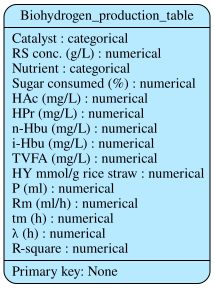

In [85]:
metadata.visualize()

# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [86]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata, # required
    enforce_min_max_values=True,
    epochs=500,
    verbose=True
)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [90]:

from sdv.single_table import GaussianCopulaSynthesizer
import numpy as np

# Clean the numerical columns in real_data before fitting the synthesizer
cleaned_real_data = real_data.copy()

# Identify numerical columns from the metadata
numerical_columns = []
for col_name, col_meta in metadata.tables[user_desired_table_name].columns.items():
    if col_meta['sdtype'] == 'numerical':
        numerical_columns.append(col_name)

for col in numerical_columns:
    # Convert column to string type first to handle mixed types safely
    cleaned_real_data[col] = cleaned_real_data[col].astype(str)
    # Remove spaces and commas
    cleaned_real_data[col] = cleaned_real_data[col].str.replace('\xa0', '', regex=False).str.replace(',', '', regex=False)
    # Convert to numeric, coercing errors to NaN
    cleaned_real_data[col] = pd.to_numeric(cleaned_real_data[col], errors='coerce')
    # Optionally, handle NaNs that might result from coercion if needed, e.g., fill with mean or median.
    # For this task, we will assume SDV can handle NaNs in numerical columns appropriately.
    # If not, a strategy like `cleaned_real_data[col].fillna(cleaned_real_data[col].mean(), inplace=True)` could be applied.

# Initialize the GaussianCopulaSynthesizer
gmm_synthesizer = GaussianCopulaSynthesizer(metadata)

# Fit the synthesizer to the cleaned real data
gmm_synthesizer.fit(cleaned_real_data)

<font color="maroon"><i><b>This step takes a few minutes.</b> For larger datasets, this phase may take longer. A drawback of a GAN-based model like CTGAN is performance.</i></font>

When this code finishes running, the synthesizer is ready to use.

## 2.2 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [94]:
# Generate synthetic data using the GMM synthesizer
synthetic_data_from_gmm = gmm_synthesizer.sample(len(real_data) * 20)

print(f"Generated {len(synthetic_data_from_gmm)} synthetic rows using GMM.")
display(synthetic_data_from_gmm.head())

Generated 680 synthetic rows using GMM.


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,47,No,97.87,5961,24,76,0.0,8816.3,0.2281,80.84,7.37,5.41,0.15,0.9976
1,HNO3,29,Yes,98.87,3199,98,189,40.3,1904.1,0.2060,15.23,0.46,13.59,0.79,0.9928
2,HNO3,24,No,96.15,4203,992,1472,2254.1,1865.8,0.2661,47.84,0.44,4.80,1.40,0.9781
3,HCl,49,Yes,20.27,5776,124,632,418.0,1636.6,0.2463,132.50,10.04,18.54,3.16,0.9982
4,HNO3,25,Yes,85.86,2495,31,93,1.9,974.4,0.2707,6.55,0.36,24.02,1.09,0.9451


In [98]:
# Use the actual numerical columns identified from the metadata
numeric_cols = numerical_columns # This variable was correctly populated in a previous step

# Calculate group-wise min/max from cleaned_real_data
group_min_max = cleaned_real_data.groupby('Catalyst')[numeric_cols].agg(['min', 'max'])

# Define a function to enforce group-wise min/max
def enforce_group_min_max_for_row(row, group_min_max_df, group_col, numeric_columns):
    catalyst_group = row[group_col]
    if catalyst_group in group_min_max_df.index:
        for col in numeric_columns:
            # These values should now be numerical, so direct float conversion is safe
            min_val = float(group_min_max_df.loc[catalyst_group, (col, 'min')])
            max_val = float(group_min_max_df.loc[catalyst_group, (col, 'max')])
            row[col] = max(min_val, min(max_val, row[col]))
    return row

# Create a copy to store the enforced synthetic data
synthetic_data_enforced = synthetic_data_from_gmm.copy()

# Apply the enforcement function to each row of the synthetic data
synthetic_data_enforced = synthetic_data_enforced.apply(lambda row: enforce_group_min_max_for_row(row, group_min_max, 'Catalyst', numeric_cols), axis=1)

print("Synthetic data after enforcing group-wise min/max values:")
display(synthetic_data_enforced.head(680))

Synthetic data after enforcing group-wise min/max values:


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,47.0,No,96.00,5961.0,24.0,76.0,0.0,8816.3,0.2281,80.84,7.37,5.41,0.15,0.9976
1,HNO3,29.0,Yes,96.00,3199.0,98.0,189.0,40.3,1904.1,0.2060,15.23,0.46,13.59,0.79,0.9928
2,HNO3,24.0,No,96.00,4203.0,601.0,1472.0,185.0,1865.8,0.2661,47.84,0.44,4.80,1.40,0.9781
3,HCl,49.0,Yes,20.27,4998.0,124.0,632.0,46.0,1636.6,0.2463,60.43,1.32,18.54,3.16,0.9982
4,HNO3,25.0,Yes,85.86,2495.0,31.0,93.0,1.9,1602.0,0.2707,12.21,0.36,24.02,1.09,0.9662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,HNO3,41.0,Yes,44.21,4494.0,111.0,3429.0,3.7,1602.0,0.0455,23.10,1.00,10.54,1.90,0.9767
676,HCl,10.0,Yes,75.17,809.0,138.0,3397.0,46.0,974.4,0.0644,4.40,0.89,9.16,10.14,0.9733
677,HNO3,13.0,No,96.00,2481.0,172.0,1129.0,72.0,1602.0,0.2906,58.81,0.33,13.26,3.91,0.9964
678,HCl,11.0,Yes,60.15,809.0,138.0,2289.0,46.0,974.4,0.1214,14.21,0.63,13.25,5.86,0.9760


In [99]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(synthetic_data_enforced)

,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
0,HNO3,47.0,No,96.00,5961.0,24.0,76.0,0.0,8816.3,0.2281,80.84,7.37,5.41,0.15,0.9976
1,HNO3,29.0,Yes,96.00,3199.0,98.0,189.0,40.3,1904.1,0.2060,15.23,0.46,13.59,0.79,0.9928
2,HNO3,24.0,No,96.00,4203.0,601.0,1472.0,185.0,1865.8,0.2661,47.84,0.44,4.80,1.40,0.9781
3,HCl,49.0,Yes,20.27,4998.0,124.0,632.0,46.0,1636.6,0.2463,60.43,1.32,18.54,3.16,0.9982
4,HNO3,25.0,Yes,85.86,2495.0,31.0,93.0,1.9,1602.0,0.2707,12.21,0.36,24.02,1.09,0.9662
5,H2SO4,25.0,No,42.28,880.0,233.0,7664.0,164.4,991.0,0.0244,26.78,3.16,8.00,2.42,0.9786
6,HNO3,46.0,Yes,23.00,5891.0,89.0,961.0,5.9,1602.0,0.0617,62.44,2.78,8.15,0.77,0.9889
7,HCl,25.0,Yes,98.87,3057.0,129.0,2532.0,46.0,2688.9,0.1868,60.43,1.32,13.46,1.68,0.9980
8,HCl,8.0,No,86.73,1367.0,106.0,3537.0,13.2,977.7,0.2562,60.43,0.92,11.73,2.50,0.9922
9,HCl,20.0,Yes,98.30,2378.0,138.0,231.0,46.0,1378.9,0.0336,60.43,0.98,27.00,9.69,0.9977


In [101]:
synthesizer.fit(cleaned_real_data)
synthetic_data = synthetic_data_enforced.sample(n=680, replace=True)
synthetic_data.head()

Gen. (-00.56) | Discrim. (-00.15): 100%|██████████| 500/500 [00:42<00:00, 11.69it/s]


,Catalyst,RS conc. (g/L),Nutrient,Sugar consumed (%),HAc (mg/L),HPr (mg/L),n-Hbu (mg/L),i-Hbu (mg/L),TVFA (mg/L),HY mmol/g rice straw,P (ml),Rm (ml/h),tm (h),λ (h),R-square
471,HCl,8.0,Yes,98.57,1759.0,138.0,3445.0,46.0,1163.6,0.0921,17.46,1.25,14.21,3.71,0.9951
616,HCl,33.0,Yes,27.00,1437.0,138.0,945.0,46.0,1937.3,0.0993,59.30,1.32,15.25,3.01,0.9978
512,HCl,17.0,No,24.66,1092.0,121.0,81.0,46.0,974.4,0.0039,2.57,0.76,14.08,3.61,0.9705
629,HCl,42.0,No,20.82,4998.0,62.0,1154.0,3.6,5676.1,0.0037,22.25,1.32,15.88,4.30,0.9822
446,H2SO4,25.0,Yes,38.70,1681.0,378.0,121.0,770.3,1212.2,0.0244,16.66,3.16,18.27,7.10,0.9971


The synthesizer is generating synthetic guests in the **same format as the original data**.

## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [104]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=cleaned_real_data,
    synthetic_data=synthetic_data_enforced,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 916.25it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 161.69it/s]|
Data Structure Score: 57.89%

Overall Score (Average): 78.95%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [105]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    cleaned_real_data,
    synthetic_data_enforced,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 503.86it/s]|
Column Shapes Score: 79.97%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 124.00it/s]|
Column Pair Trends Score: 73.53%

Overall Score (Average): 76.75%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [106]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Catalyst,TVComplement,0.892647
1,RS conc. (g/L),KSComplement,0.732353
2,Nutrient,TVComplement,0.941176
3,Sugar consumed (%),KSComplement,0.847059
4,HAc (mg/L),KSComplement,0.847059
5,HPr (mg/L),KSComplement,0.695588
6,n-Hbu (mg/L),KSComplement,0.733824
7,i-Hbu (mg/L),KSComplement,0.701471
8,TVFA (mg/L),KSComplement,0.557353
9,HY mmol/g rice straw,KSComplement,0.773529


## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [108]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=cleaned_real_data,
    synthetic_data= synthetic_data_enforced,
    column_name='Catalyst',
    metadata=metadata
)

fig.show()

We can also visualize in 2D, comparing the correlations of a pair of columns.

In [109]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=cleaned_real_data,
    synthetic_data=synthetic_data_enforced,
    column_names=['Catalyst', 'RS conc. (g/L)', 'HY mmol/g rice straw'],
    metadata=metadata
)

fig.show()

ValueError: Must provide exactly two column names.

In [110]:
from sdv.evaluation.single_table import get_column_pair_plot

fig_catalyst_rs_conc = get_column_pair_plot(
    real_data=cleaned_real_data,
    synthetic_data=synthetic_data_enforced,
    column_names=['Catalyst', 'RS conc. (g/L)'],
    metadata=metadata
)

fig_catalyst_rs_conc.show()

In [111]:
from sdv.evaluation.single_table import get_column_pair_plot

fig_catalyst_hy = get_column_pair_plot(
    real_data=cleaned_real_data,
    synthetic_data=synthetic_data_enforced,
    column_names=['Catalyst', 'HY mmol/g rice straw'],
    metadata=metadata
)

fig_catalyst_hy.show()

### Cumulative Distribution Function (CDF) Plots for Numerical Features

These plots show the cumulative distribution for each numerical column, allowing us to see how well the synthetic data's distribution matches the real data's distribution.

Generating CDF plot for: RS conc. (g/L)


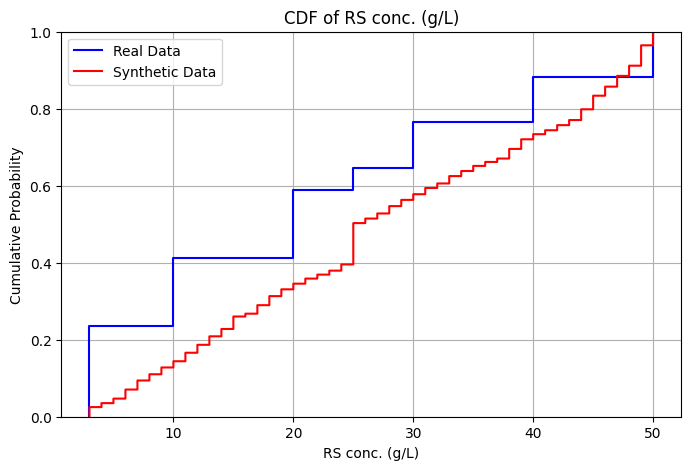

Generating CDF plot for: Sugar consumed (%)


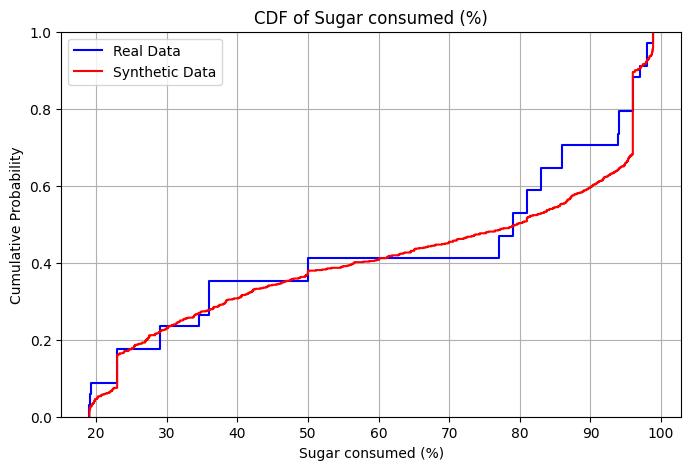

Generating CDF plot for: HAc (mg/L)


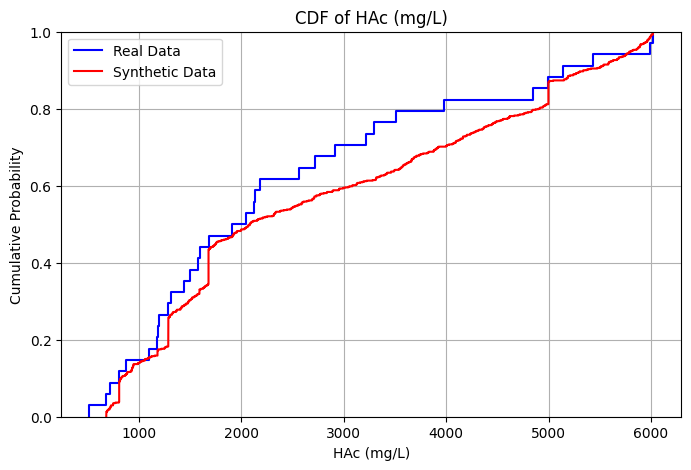

Generating CDF plot for: HPr (mg/L)


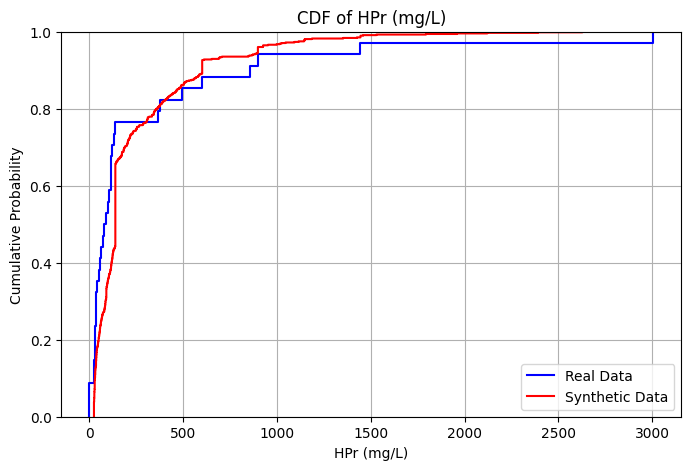

Generating CDF plot for: n-Hbu (mg/L)


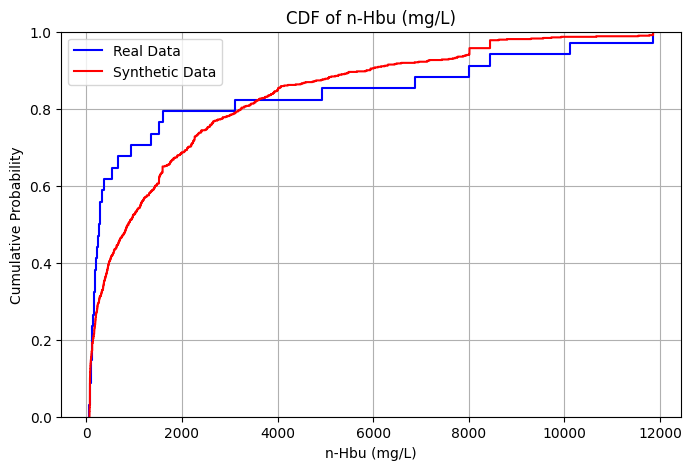

Generating CDF plot for: i-Hbu (mg/L)


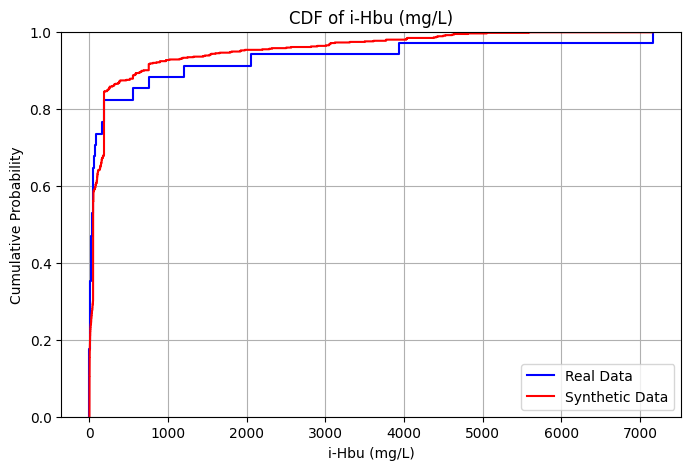

Generating CDF plot for: TVFA (mg/L)


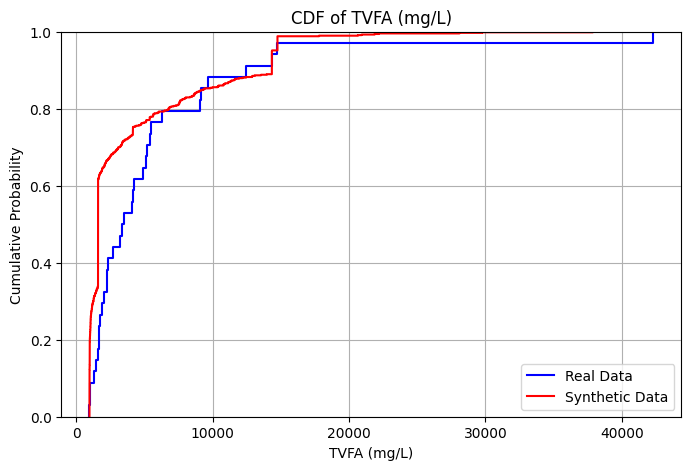

Generating CDF plot for: HY mmol/g rice straw


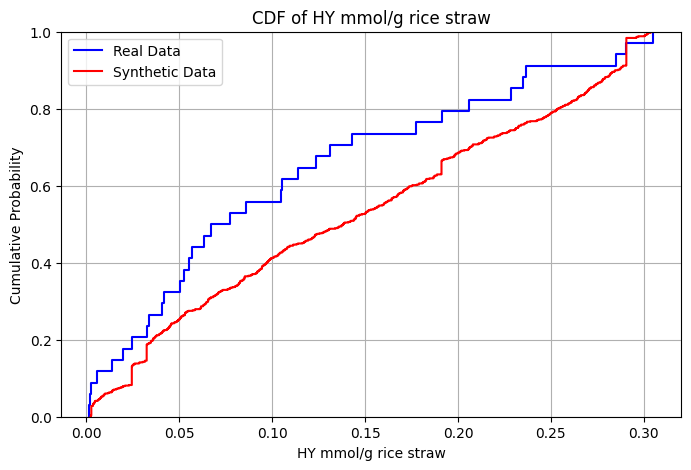

Generating CDF plot for: P (ml)


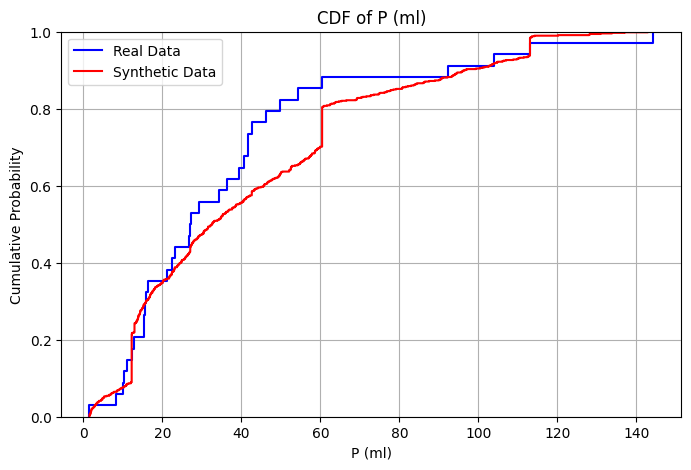

Generating CDF plot for: Rm (ml/h)


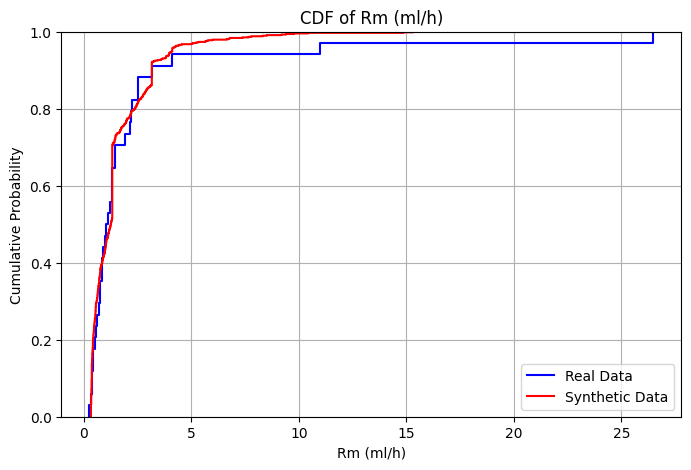

Generating CDF plot for: tm (h)


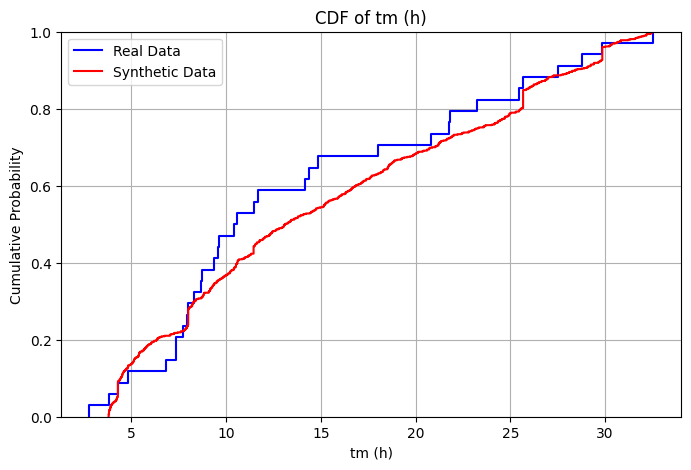

Generating CDF plot for: λ (h)


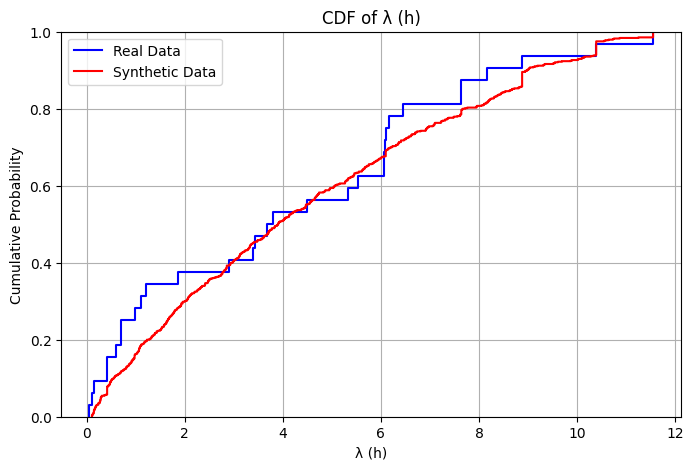

Generating CDF plot for: R-square


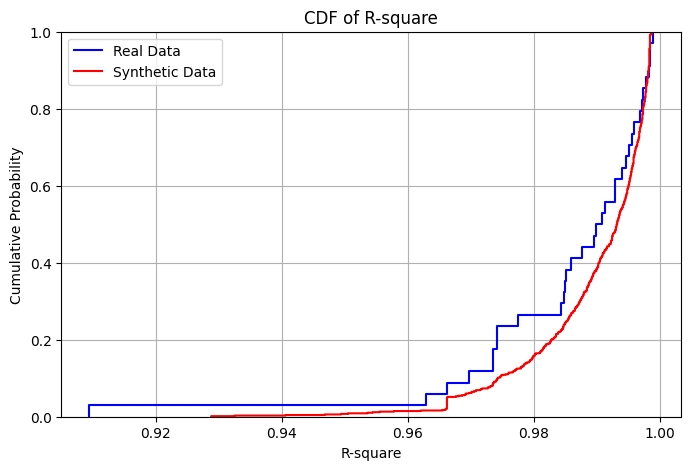

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

for col_name in numerical_columns:
    print(f"Generating CDF plot for: {col_name}")
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(data=cleaned_real_data, x=col_name, label='Real Data', color='blue')
    sns.ecdfplot(data=synthetic_data_enforced, x=col_name, label='Synthetic Data', color='red')
    plt.title(f'CDF of {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True)
    plt.show()

## 2.5 Anonymization

In the original dataset, we had some sensitive columns such as the guest's email, billing address and phone number. In the synthetic data, these columns are **fully anonymized** -- they contain entirely fake values that follow the format of the original.

PII columns are not included in the quality report, but we can inspect them to see that they are different.

In [ ]:
sensitive_column_names = ['guest_email', 'billing_address', 'credit_card_number']

real_data[sensitive_column_names].head(3)

,guest_email,billing_address,credit_card_number
0,michaelsanders@shaw.net,"49380 Rivers Street\nSpencerville, AK 68265",4075084747483975747
1,randy49@brown.biz,"88394 Boyle Meadows\nConleyberg, TN 22063",180072822063468
2,webermelissa@neal.com,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",38983476971380


In [ ]:
synthetic_data[sensitive_column_names].head(3)

,guest_email,billing_address,credit_card_number
0,dsullivan@example.net,"90469 Karla Knolls Apt. 781\nSusanberg, CA 70033",5161033759518983
1,steven59@example.org,"6108 Carla Ports Apt. 116\nPort Evan, MI 71694",4133047413145475690
2,brandon15@example.net,86709 Jeremy Manors Apt. 786\nPort Garychester...,4977328103788


## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [ ]:
synthesizer.save('my_synthesizer.pkl')

In [ ]:
from sdv.utils import load_synthesizer

synthesizer = load_synthesizer('my_synthesizer.pkl')
synthesizer.sample(num_rows=3)

,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,cburns@example.com,False,BASIC,NaN,07 Jan 2021,29 Feb 2020,131.16,Unit 7909 Box 7283\nDPO AA 48458,30158284644887
1,jordanpamela@example.org,False,BASIC,12.15,26 Oct 2020,30 Sep 2020,133.41,"0837 Stewart Pike Suite 951\nPort Zachary, IA ...",4375705762878737
2,amanda33@example.org,False,BASIC,10.98,18 Jul 2020,07 Jan 2020,424.84,"24644 Pollard Burgs Apt. 192\nSarahview, PA 78396",180027361090256


# 3. CTGAN Customization
When using this synthesizer, we can make a tradeoff between training time and data quality using the `epochs` parameter: Higher `epochs` means that the synthesizer will train for longer, and ideally improve the data quality.

To see the progress, we can also turn on the `verbose` parameter. This will show a progress bar that will fill up as the synthesizer completes the fit process.


In [ ]:
custom_synthesizer = CTGANSynthesizer(
    metadata,
    epochs=1000,
    verbose=True)
custom_synthesizer.fit(real_data)

Gen. (-0.93) | Discrim. (-0.21): 100%|██████████| 1000/1000 [01:03<00:00, 15.86it/s]


<font color="maroon"><i><b>This code takes longer to run.</b></i></font>

After we've trained our synthesizer, we can verify the changes to the data quality by creating some synthetic data and evaluating it.

In [ ]:
synthetic_data_customized = custom_synthesizer.sample(num_rows=500)

quality_report = evaluate_quality(
    real_data,
    synthetic_data_customized,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 574.60it/s]|
Column Shapes Score: 82.86%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 412.45it/s]|
Column Pair Trends Score: 72.36%

Overall Score (Average): 77.61%



While GANs are able to model complex patterns and shapes, it is not easy to understand how they are learning -- but it is possible to modify the underlying architecture of the neural networks.

For users who are familiar with the GAN architecture, there are extra parameters you can use to tune CTGAN to your particular needs. For more details, see [the CTGAN documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer).

# 4. What's Next?

For more information about the CTGAN Synthesizer, visit the **[documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer)**.

⭐ To learn about other SDV features, [browse all tutorials](https://docs.sdv.dev/sdv/demos)

⭐ **Need more help?** [Visit our forum](https://forum.datacebo.com/) for troubleshooting, questions, or general feedback.

---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.

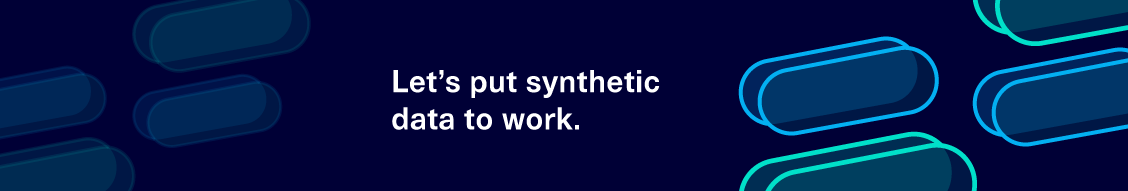